# Chapter 01 재구매 고객 분석

강사 제공 공개 데이터를 사용해 질문 정의, 데이터 검증, 계산, 해석의 흐름을 재현합니다.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
print('import 완료')

import 완료


In [2]:
BASE = 'https://raw.githubusercontent.com/GilbertMoon/llm-data-analysis-course/main/data/raw'

customers = pd.read_csv(f'{BASE}/customers.csv')
products = pd.read_csv(f'{BASE}/products.csv')
orders = pd.read_csv(f'{BASE}/orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(f'{BASE}/order_items.csv')

pd.DataFrame({
    '파일': ['customers.csv', 'products.csv', 'orders.csv', 'order_items.csv'],
    '행 수': [len(customers), len(products), len(orders), len(order_items)],
    '결측 수': [customers.isna().sum().sum(), products.isna().sum().sum(), orders.isna().sum().sum(), order_items.isna().sum().sum()],
})

,파일,행 수,결측 수
0,customers.csv,150,0
1,products.csv,100,0
2,orders.csv,300,0
3,order_items.csv,764,0


In [3]:
# PK와 FK 관계 검증
checks = {
    'customers.customer_id PK': customers['customer_id'].is_unique,
    'products.product_id PK': products['product_id'].is_unique,
    'orders.order_id PK': orders['order_id'].is_unique,
    'order_items.order_item_id PK': order_items['order_item_id'].is_unique,
    'orders → customers FK': set(orders['customer_id']).issubset(set(customers['customer_id'])),
    'order_items → orders FK': set(order_items['order_id']).issubset(set(orders['order_id'])),
    'order_items → products FK': set(order_items['product_id']).issubset(set(products['product_id'])),
}
pd.Series(checks, name='검증 결과')

customers.customer_id PK        True
products.product_id PK          True
orders.order_id PK              True
order_items.order_item_id PK    True
orders → customers FK           True
order_items → orders FK         True
order_items → products FK       True
Name: 검증 결과, dtype: bool

In [4]:
completed = orders.loc[orders['order_status'].eq('completed')].sort_values(['order_date', 'order_id']).copy()
completed_counts = completed.groupby('customer_id').size()
repeat_customers = completed_counts[completed_counts.ge(2)].index

result = pd.Series({
    'completed 주문 수': len(completed),
    'completed 구매 고객 수': completed_counts.index.nunique(),
    '재구매 고객 수(2회 이상)': len(repeat_customers),
    '재구매 고객 비율': len(repeat_customers) / completed_counts.index.nunique(),
})
result

completed 주문 수       184.00
completed 구매 고객 수    100.00
재구매 고객 수(2회 이상)       56.00
재구매 고객 비율              0.56
dtype: float64

In [5]:
# 월별 비율: 해당 월 completed 구매 고객 중 월 시작 전 completed 구매 이력이 있는 고객 비율
completed['month'] = completed['order_date'].dt.to_period('M')
rows = []
for month, group in completed.groupby('month', sort=True):
    active = set(group['customer_id'])
    prior = set(completed.loc[completed['order_date'].lt(month.start_time), 'customer_id'])
    repeat_active = active & prior
    rows.append({
        'month': str(month),
        'completed_orders': len(group),
        'active_customers': len(active),
        'repeat_customers': len(repeat_active),
        'repeat_share': len(repeat_active) / len(active),
    })

monthly = pd.DataFrame(rows)
monthly

,month,completed_orders,active_customers,repeat_customers,repeat_share
0,2025-07,8,8,0,0.000000
1,2025-08,18,18,1,0.055556
2,2025-09,13,13,1,0.076923
3,2025-10,26,26,5,0.192308
4,2025-11,12,12,6,0.500000
5,2025-12,14,14,5,0.357143
6,2026-01,22,20,9,0.450000
7,2026-02,17,16,9,0.562500
8,2026-03,14,13,12,0.923077
9,2026-04,23,22,18,0.818182


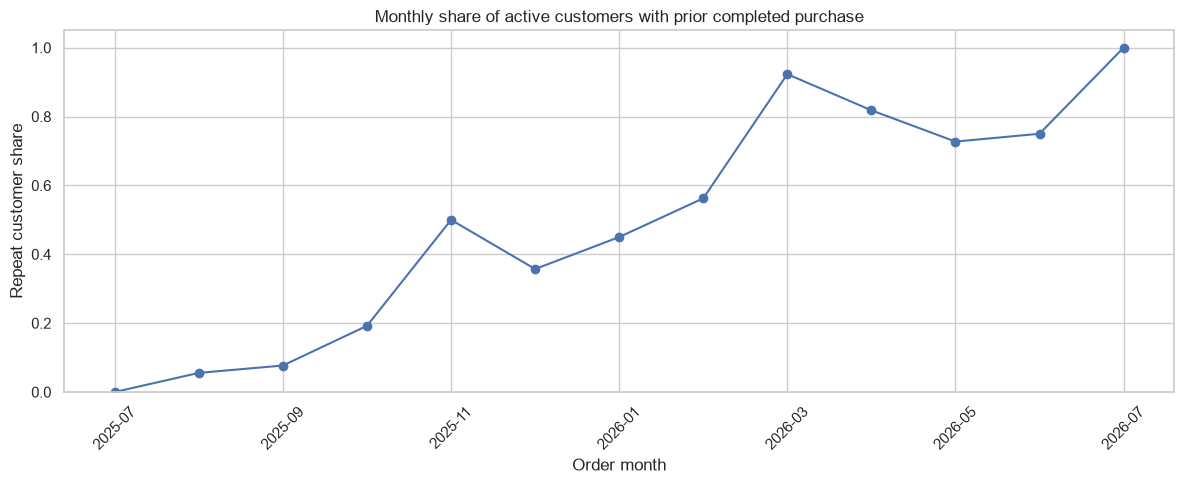

In [6]:
ax = monthly.plot(x='month', y='repeat_share', marker='o', figsize=(12, 5), legend=False)
ax.set_title('Monthly share of active customers with prior completed purchase')
ax.set_xlabel('Order month')
ax.set_ylabel('Repeat customer share')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 해석

기간 전체에서 completed 주문 고객 100명 중 2회 이상 구매한 고객은 56명으로 56%입니다. 월별 비율은 분석 후반에 높아지지만, 첫 달 이전 구매 이력이 데이터에 없고 마지막 달은 일부 기간만 포함하므로 시간에 따른 상승이나 프로모션 효과를 단정할 수 없습니다.